In [1]:
import helper
import importlib
importlib.reload(helper)
from helper import planner_node, agent_system_prompt
from langgraph.prebuilt import create_react_agent
from langgraph.types import Command
from langgraph.graph import START, END, StateGraph
from langchain_tavily import TavilySearch
from langchain_community.tools.tavily_search import TavilySearchResults

In [2]:
from langchain_community.tools.tavily_search import TavilySearchResults

1. Let's load the environment variables that define the Groq API and Tavily API keys.

In [3]:
from dotenv import load_dotenv
import warnings

# Suppress warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*create_react_agent.*")

_ = load_dotenv(override=True)

2. Initialize the agent's state

In [4]:
# %pip install langgraph

from typing import Literal, Optional, List, Dict, Any, Type
from langgraph.graph import MessagesState

# Custom State class with specific keys
class State(MessagesState):
    user_query: Optional[str] # The user's original query
    enabled_agents: Optional[List[str]] # Makes our multi-agent system modular on which agents to include
    plan: Optional[List[Dict[int, Dict[str, Any]]]] # Listing the steps in the plan needed to achieve the goal.
    current_step: int # Marking the current step in the plan.
    agent_query: Optional[str] # Inbox note: `agent_query` tells the next agent exactly what to do at the current step.
    last_reason: Optional[str] # Explains the executor’s decision to help maintain continuity and provide traceability.
    replan_flag: Optional[bool] # Set by the executor to indicate that the planner should revise the plan.
    replan_attempts: Optional[Dict[int, Dict[int, int]]] # Replan attempts tracked per step number.

3. Create planner

In [5]:
# %pip install langchain
# %pip install langchain-core
# %pip install langchain-groq

from prompts import plan_prompt
from langgraph.types import Command
from langchain_core.messages import HumanMessage
from langchain_groq import ChatGroq

import json
import re

def parse_json_from_markdown(text):
    """Refined parser that can handle markdown code blocks."""
    try:
        # Try direct parsing first
        return json.loads(text)
    except json.JSONDecodeError:
        pass
    
    # Try removing markdown code blocks
    pattern = r"```(?:json)?\s*(.*?)\s*```"
    match = re.search(pattern, text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(1))
        except json.JSONDecodeError:
            pass
            
    # Raise error if all fails
    raise ValueError(f"Could not parse JSON from text: {text}")

In [6]:
reasoning_llm = ChatGroq(
    model="llama-3.1-8b-instant",
    model_kwargs={"response_format": {"type": "json_object"}}, 
    # Llama 3 on Groq usually follows instructions well, but we'll use robust parsing.
)

In [7]:
def planner_node(state: State) -> Command[Literal['executor']]:
    """
    Runs the planning LLM and stores the resulting plan in state.
    """
    # 1. Invoke LLM with the planner prompt
    llm_reply = reasoning_llm.invoke([plan_prompt(state)])

    # 2. Validate JSON
    try:
        content_str = llm_reply.content if isinstance(
            llm_reply.content, str) else str(llm_reply.content)
        parsed_plan = parse_json_from_markdown(content_str)
    except ValueError as e:
        raise ValueError(
            f"Planner returned invalid JSON:\n{llm_reply.content}") from e

    # 3. Store as current plan only
    replan = state.get("replan_flag", False)
    updated_plan: Dict[str, Any] = parsed_plan

    return Command(
        update={
            "plan": updated_plan,
            "messages": [HumanMessage(
                content=llm_reply.content,
                name="replan" if replan else "initial_plan")],
            "user_query": state.get("user_query", state["messages"][0].content),"current_step": 1 if not replan else state["current_step"],
            # Preserve replan flag so executor runs planned agent
            # once before reconsidering
            "replan_flag": state.get("replan_flag", False),
            "last_reason": "",
            "enabled_agents": state.get("enabled_agents"),
        },
        goto="executor",
    )

4. Create executor

In [8]:
from prompts import executor_prompt

In [9]:
from langgraph.graph import END

In [10]:
MAX_REPLANS = 3

In [11]:
def executor_node(
    state: State,
) -> Command[Literal["web_researcher", "chart_generator", "chart_summarizer", "synthesizer", "planner"]]:

    plan: Dict[str, Any] = state.get("plan", {})
    step: int = state.get("current_step", 1)

    # 0) If we *just* replanned, 
    # run the planned agent once before reconsidering.
    if state.get("replan_flag"):
        planned_agent = plan.get(str(step), {}).get("agent")
        # Safety check: if plan is somehow missing this step, go to planner or fail gracefully
        if not planned_agent:
            return Command(update={"replan_flag": False}, goto="planner")
            
        # SANITIZATION (for replan path)
        valid_agents = ["web_researcher", "chart_generator", "chart_summarizer", "synthesizer", "planner"]
        if planned_agent not in valid_agents:
             if isinstance(planned_agent, str):
                 splitted = planned_agent.replace("|", ",").split(",")
                 top_choice = splitted[0].strip()
                 if top_choice in valid_agents:
                     planned_agent = top_choice
                 else:
                     planned_agent = "synthesizer"
             else:
                 planned_agent = "synthesizer"

        return Command(
            update={
                "replan_flag": False,
                "current_step": step + 1,  # advance because we executed the planned agent
            },
            goto=planned_agent,
        )

    # 1) Build prompt & call LLM
    llm_reply = reasoning_llm.invoke([executor_prompt(state)])
    try:
        content_str = llm_reply.content if isinstance(llm_reply.content, str) else str(llm_reply.content)
        parsed = parse_json_from_markdown(content_str)
        
        # Force alignment with plan if not replanning
        if not parsed.get("replan"):
             planned_agent = plan.get(str(step), {}).get("agent")
             if planned_agent:
                 parsed["goto"] = planned_agent
        
    except ValueError as e:
        raise ValueError(f"Executor returned invalid JSON:\n{llm_reply.content}") from e

    # 2) Extract decision
    replan = parsed.get("replan", False)
    goto   = parsed.get("goto")
    agent_query = parsed.get("query")
    reason = parsed.get("reason", "")

    # Handle end-of-plan or missing goto
    if not replan and not goto:
        # Check if we are past the end of the plan
        if str(step) not in plan:
             # Assume completion -> synthesizer
             goto = "synthesizer"
        else:
             # Fallback: if plan exists but logic failed, follow plan
             goto = plan.get(str(step), {}).get("agent")
             
    # Final safety net
    if not goto and not replan:
        goto = "synthesizer" # Default to wrap up if completely lost

    # SANITIZATION (for parsed/fallback path)
    valid_agents = ["web_researcher", "chart_generator", "chart_summarizer", "synthesizer", "planner"]
    if not replan and goto not in valid_agents:
         if isinstance(goto, str):
             # Handle piped "agent | agent" or comma "agent, agent"
             splitted = goto.replace("|", ",").split(",")
             top_choice = splitted[0].strip()
             if top_choice in valid_agents:
                 goto = top_choice
             else:
                 # Try to find any valid agent in the string
                 found = next((v for v in valid_agents if v in goto), None)
                 goto = found if found else "synthesizer"
         else:
             goto = "synthesizer"

    if replan:
        return Command(
            update={
                "replan_flag": True,
                "agent_query": agent_query, # feedback to planner
            },
            goto="planner",
        )
            
    return Command(
        update={
            "agent_query": agent_query,
            "last_reason": reason,
            "current_step": step + 1,
        },
        goto=goto,
    )

5. Create Web research agent

In [12]:
tavily_tool = TavilySearchResults(max_results=1)
# tavily_tool.invoke("What is JP Morgan's stock price?")['results']

In [13]:
from helper import agent_system_prompt

llm = ChatGroq(model="llama-3.1-8b-instant")

# Research agent and node
web_search_agent = create_react_agent(
    llm,
    tools=[tavily_tool],
    prompt=agent_system_prompt(f"""
        You are the Researcher. You can ONLY perform research 
        by using the provided search tool (tavily_tool). 
        When you have found the necessary information, end your output.  
        Do NOT attempt to take further actions.
        KEEP RESULTS VERY BRIEF.
        
        IMPORTANT: Provide ONLY the JSON arguments for tools. Do not wrap the tool call in XML tags or markdown.
        Do NOT use <function=...> tags.
    """),
)

In [14]:
agent_response = web_search_agent.invoke(
    {"messages":"what is jp morgan's current market cap?"})

In [15]:
agent_response['messages'][-1].content

'tavily_search_results_json{"query": "JP Morgan market cap"}'

In [16]:
def web_research_node(
    state: State,
) -> Command[Literal["executor"]]:
    agent_query = state.get("agent_query")
    result = web_search_agent.invoke({"messages":agent_query})
    goto = "executor"
    
    # Extract ONLY the final response to save tokens and avoid passing raw Tool outputs to the next agent
    # Also truncate if excessively long to prevent 413 errors
    final_content = result["messages"][-1].content
    if len(final_content) > 3000:
        final_content = final_content[:3000] + "... (truncated)"
        
    final_message = HumanMessage(
        content=final_content, 
        name="web_researcher"
    )
    
    return Command(
        update={
            # Add only the summary message to the global history
            "messages": [final_message],
        },
        goto=goto,
    )

6. Create charting agent

In [17]:
from helper import python_repl_tool

# Chart generator agent and node
# NOTE: THIS PERFORMS ARBITRARY CODE EXECUTION, 
# WHICH CAN BE UNSAFE WHEN NOT SANDBOXED
chart_agent = create_react_agent(
    llm,
    [python_repl_tool],
    prompt=agent_system_prompt(
        """
        You can only generate charts. You are working with a researcher 
        colleague.
        
        Instructions:
        1. SOURCE DATA: You must extract the numerical data (Market Caps, Stock Prices, etc.) directly from the conversation history.
        2. DO NOT try to fetch data from APIs or external files in your Python code. HARDCODE the data into lists/dictionaries in the Python code.
        3. Start your python code with `import warnings; warnings.filterwarnings('ignore')` to suppress dependencies warnings.
        4. Generate the chart using matplotlib.
        5. Make sure all columns are filled with color (e.g. `color='skyblue'`) and edges are distinct (`edgecolor='black'`). 
        6. Add data labels on top of the bars to make values clear.
        7. VITAL: Use `plt.xticks(rotation=45, ha='right')` to rotate labels so they don't overlap.
        8. VITAL: Use `plt.tight_layout()` before saving to ensure no labels (especially specific bank names) are cut off.
        9. Save the chart to a temporary file named exactly matches with "temp_chart.png".
        10. Print "Chart saved to temp_chart.png" in your code.
        11. DO NOT use `plt.show()`. Only save the file.
        12. At the very end of your final response message, output EXACTLY two lines 
           so the summarizer and system can find them:
           CHART_PATH: temp_chart.png
           CHART_NOTES: <one concise sentence summarizing the main insight in the chart>
        
        Do not include any other trailing text after these two lines.
        IMPORTANT: Provide ONLY the JSON arguments for tools. Do not wrap the tool call in XML tags or markdown.
        Do NOT use <function=...> tags.
        """
    ),
)

In [18]:
from IPython.display import Image, display
import re
import os
import contextlib
import io
import matplotlib.pyplot as plt
from langchain_experimental.utilities import PythonREPL
import helper

def chart_node(state: State) -> Command[Literal["chart_summarizer"]]:
    result = chart_agent.invoke(state)
    
    # Extract the last message content
    last_msg = result["messages"][-1]
    content = last_msg.content
        
    # Check if a chart tool was actually called? 
    # If not, and we see code, execute it manually (Fallback for Llama 3)
    # Also check for temp_chart.png specifically
    chart_file = "temp_chart.png"
    
    # Check if file exists (from tool call)
    if not os.path.exists(chart_file) and os.path.exists("chart.png"):
        chart_file = "chart.png"

    if not os.path.exists(chart_file):
        # Extract code blocks
        code_blocks = re.findall(r"```python\s*(.*?)\s*```", content, re.DOTALL)
        
        # Decide which REPL to use (prefer helper.repl to avoid warning)
        try:
             repl = helper.repl
        except (AttributeError, NameError):
             with contextlib.redirect_stdout(io.StringIO()):
                 repl = PythonREPL()

        if code_blocks:
            for code in code_blocks:
                try:
                    # Patch code to use temp_chart.png if it uses chart.png
                    if "chart.png" in code and "temp_chart.png" not in code:
                            code = code.replace("chart.png", "temp_chart.png")
                    
                    # Remove plt.show() to prevent duplicate display
                    code = code.replace("plt.show()", "")

                    # Ensure matplotlib is imported if missing
                    if "import matplotlib.pyplot" not in code and "plt." in code:
                        code = "import matplotlib.pyplot as plt\n" + code

                    _ = repl.run(code)
                except Exception as e:
                    pass
        else:
             # Heuristic for code not in blocks
             pattern = r"(import\s+matplotlib.*?|from\s+matplotlib.*?)(\n\s*plt\..*)"
             if re.search(pattern, content, re.DOTALL):
                 # Try to grab the code block if it's not in markdown
                 code_part = content.split("CHART_PATH:")[0]
                 
                 try:
                    if "chart.png" in code_part and "temp_chart.png" not in code_part:
                            code_part = code_part.replace("chart.png", "temp_chart.png")
                    
                    code_part = code_part.replace("plt.show()", "")
                    
                    if "import matplotlib.pyplot" not in code_part and "plt." in code_part:
                        code_part = "import matplotlib.pyplot as plt\n" + code_part

                    _ = repl.run(code_part)
                 except Exception as e:
                    pass

    # Try to find the chart path to display it
    match = re.search(r"CHART_PATH:\s*(.*)", content)
    found_chart = False
    
    if match:
        chart_path_in_msg = match.group(1).strip().strip("'\"")
        if os.path.exists(chart_path_in_msg):
            chart_file = chart_path_in_msg
            found_chart = True
    
    if not found_chart and os.path.exists(chart_file):
         found_chart = True

    if found_chart:
        try:
            # Display the image explicitly
            display(Image(filename=chart_file))
            
            # CLEANUP: Remove the file after displaying so it doesn't persist
            os.remove(chart_file)
        except Exception as e:
            pass
    
    # CRITICAL FIX: Explicitly close any open matplotlib figures.
    # This prevents IPython from automatically displaying the "active figure"
    # again at the end of the cell execution, which causes the double image.
    try:
        plt.close('all')
    except Exception:
        pass
    
    # wrap in a human message
    result["messages"][-1] = HumanMessage(
        content=content, name="chart_generator"
    )
    
    goto="chart_summarizer"
    return Command(
        update={
            "messages": result["messages"],
        },
        goto=goto,
    )

7. Create chart summary agent

In [19]:
chart_summary_agent = create_react_agent(
    llm,
    tools=[],  # Add image processing tools if available/needed.
    prompt=agent_system_prompt(
        "You can only generate image captions. You are working with a researcher colleague and a chart generator colleague. "
        + "Your task is to generate a standalone, concise summary for the provided chart image saved at a local PATH, where the PATH should be and only be provided by your chart generator colleague. The summary should be no more than 3 sentences and should not mention the chart itself."
    ),
)

In [20]:
def chart_summary_node(
    state: State,
) -> Command[Literal[END]]:
    result = chart_summary_agent.invoke(state)
    # Send to the end node
    goto = END
    return Command(
        update={
            # share internal message history of chart agent with other agents
            "messages": result["messages"],
            "final_answer": result["messages"][-1].content,
        },
        goto=goto,
    )

8. Create a Synthesizer (Text Summarizer) Agent

In [21]:
llm = ChatGroq(model="llama-3.1-8b-instant")

In [22]:
def synthesizer_node(state: State) -> Command[Literal[END]]:
    """
    Creates a concise, human‑readable summary of the entire interaction,
    **purely in prose**.

    It ignores structured tables or chart IDs and instead rewrites the
    relevant agent messages (research results, chart commentary, etc.)
    into a short final answer.
    """
    # Gather informative messages for final synthesis
    relevant_msgs = [
        m.content for m in state.get("messages", [])
        if getattr(m, "name", None) in ("web_researcher", 
                                        "chart_generator", 
                                        "chart_summarizer")
    ]

    user_question = state.get("user_query", state.get("messages", [{}])[0].content if state.get("messages") else "")

    synthesis_instructions = (
        """
        You are the Synthesizer. Use the context below to directly 
        answer the user's question. Perform any lightweight calculations, 
        comparisons, or inferences required. Do not invent facts not 
        supported by the context. If data is missing, say what's missing
        and, if helpful, offer a clearly labeled best-effort estimate 
        with assumptions.\n\n
        Produce a concise response that fully answers the question, with 
        the following guidance:\n
        - Start with the direct answer (one short paragraph or a tight bullet list).\n
        - Include key figures from any 'Results:' tables (e.g., totals, top items).\n
        - If any message contains citations, include them as a brief 'Citations: [...]' line.\\n
        - Keep the output crisp; avoid meta commentary or tool instructions.
        """
        )

    summary_prompt = [
        HumanMessage(content=(
            f"User question: {user_question}\n\n"
            f"{synthesis_instructions}\n\n"
            f"Context:\n\n" + "\n\n---\n\n".join(relevant_msgs)
        ))
    ]

    llm_reply = llm.invoke(summary_prompt)

    answer = llm_reply.content.strip()
    print(answer)

    return Command(
        update={
            "final_answer": answer,
            "messages": [HumanMessage(content=answer, name="synthesizer")],
        },
        goto=END,           # hand off to the END node
    )

9. Build the agent graph

In [23]:
from langgraph.graph import START, StateGraph

workflow = StateGraph(State)
workflow.add_node("planner", planner_node)
workflow.add_node("executor", executor_node)
workflow.add_node("web_researcher", web_research_node)
workflow.add_node("chart_generator", chart_node)
workflow.add_node("chart_summarizer", chart_summary_node)
workflow.add_node("synthesizer", synthesizer_node)

workflow.add_edge(START, "planner")

graph = workflow.compile()

9. Use the agent

Python REPL can execute arbitrary code. Use with caution.


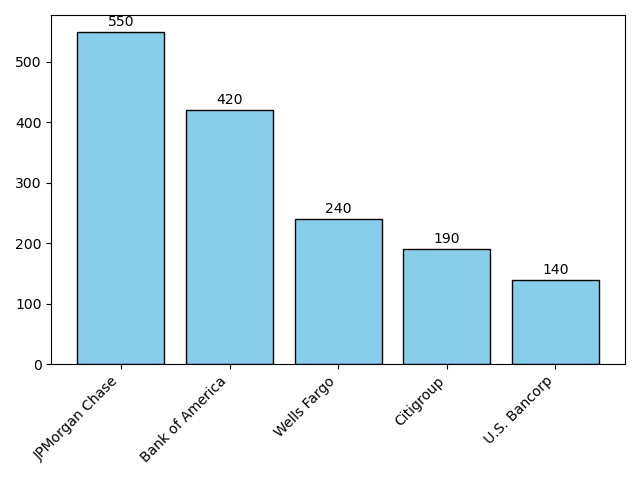

In [24]:
from langchain_core.messages import HumanMessage
import json

query = "Chart the current market capitalization of the top 5 banks in the US?"

state = {
            "messages": [HumanMessage(content=query)],
            "user_query": query,
            "enabled_agents": ["web_researcher", "chart_generator", 
                               "chart_summarizer", "synthesizer"],
        }
# Suppress final output of invoke
_ = graph.invoke(state)

In [25]:
query = "Identify current regulatory changes for the financial services industry in the US."

state = {
            "messages": [HumanMessage(content=query)],
            "user_query": query,
            "enabled_agents": ["web_researcher", "chart_generator", 
                               "chart_summarizer", "synthesizer"],
        }
_ = graph.invoke(state)

**Direct Answer:**

The US financial services industry is subject to various regulatory changes and proposals. Some of the current key regulatory changes include:

* The Securities and Exchange Commission (SEC) proposing rule changes to enhance cybersecurity and data protection (SEC Release No. 33-11038, 2022).
* The Financial Stability Oversight Council (FSOC) proposing changes to the Volcker Rule (2022).
* The Office of the Comptroller Currency (OCC) proposing revisions to the Community Reinvestment Act (2022).
* The Consumer Financial Protection Bureau (CFPB) proposing changes to the Ability-to-Repay/Qualified Mortgage Rule (2022).

**Citations:**

SEC Release No. 33-11038 (2022), FSOC (2022), OCC (2022), CFPB (2022)

**Additional Information:**

The proposed changes aim to strengthen financial regulation, improve cybersecurity, and enhance consumer protection. However, the exact timeline and implementation details for these changes are not yet available.

**Missing Information:**

